In [43]:
import numpy as np
import tools
import matplotlib.pyplot as plt
import constrct_atmosphere as CA
import pandas as pd
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad

In [2]:
# Parameters for GJ 436b
Mp = 22.1*tools.ME  # Planet mass in [kg]
rp = 0.37*tools.RJ  # Planet radius in [m]
mu_hs = 2.35  # mean molecular weight of the bolometric heated region, assumed to be fully molecular
mu_wind = 1.08 # mean molecular weight of the wind, assumed to be fully ionised and atomic
T_eq = 700 # eqilibrium temperature in [K]

sigma_XUV = 1.89e-22 # The cross-section to XUV radiation in [m^2]
eff = 0.1 # efficiency of the energy-limited mass-loss, [unitless]
kappa_IR = 0.001 # opacity at the photosphere in [m^2/kg]
FXUV = 0.45 # The XUV flux received by the planet in [W/m^2].


vs_eq = CA.get_vs(T_eq,mu_hs)
rho_p = CA.get_rho_p(rp,Mp,kappa_IR,vs_eq)

rXUV, vs_wind, T_wind, rs_wind, Mdot = CA.solve_atmosphere(rp, Mp, FXUV, eff, mu_wind, vs_eq, rho_p, sigma_XUV)

In [3]:
# Define the radial domain array 'r':
# Start the array at planet's radius
# and extend it far past the sonic point (e.g., 8 * RJ)
r_start = 1*rp
r_end = 5*rp

# Create 250 logarithmically spaced points between the start and end radii
# This ensures good resolution near the planet (subsonic region) and far out.
r_range = np.logspace(np.log10(r_start), np.log10(r_end), 250)

v_profile = CA.get_parker_wind(r_range, vs_wind, rs_wind)
rho_profile = Mdot / (4 * np.pi * r_range**2 * v_profile)

Calculate an array of tau at each r point from rmax down to rXUV 

In [4]:
# 1. Reverse the arrays to integrate from the top down (r_max to rXUV)

n = rho_profile/(mu_wind * tools.u) # number density array in [1/m^3]
n_rev = n[::-1] # reverse the number density array

r_rev = r_range[::-1]

# 2. Perform the cumulative integral of (n * dr)
# initial=0 ensures the array length matches your grid, setting tau=0 at the very top
col_density_rev = np.abs(cumulative_trapezoid(n_rev, r_rev, initial=0))

# 3. Multiply by cross-section and reverse back to match your original 'r' grid
tau = sigma_XUV * col_density_rev[::-1]

tau

array([4.22297576e+00, 3.94900236e+00, 3.69479944e+00, 3.45881663e+00,
       3.23963385e+00, 3.03594971e+00, 2.84657092e+00, 2.67040280e+00,
       2.50644060e+00, 2.35376165e+00, 2.21151822e+00, 2.07893106e+00,
       1.95528350e+00, 1.83991613e+00, 1.73222187e+00, 1.63164161e+00,
       1.53766013e+00, 1.44980243e+00, 1.36763041e+00, 1.29073978e+00,
       1.21875730e+00, 1.15133821e+00, 1.08816392e+00, 1.02893991e+00,
       9.73393745e-01, 9.21273336e-01, 8.72345304e-01, 8.26393492e-01,
       7.83217613e-01, 7.42631992e-01, 7.04464435e-01, 6.68555171e-01,
       6.34755897e-01, 6.02928894e-01, 5.72946217e-01, 5.44688950e-01,
       5.18046521e-01, 4.92916077e-01, 4.69201901e-01, 4.46814882e-01,
       4.25672025e-01, 4.05695999e-01, 3.86814721e-01, 3.68960974e-01,
       3.52072050e-01, 3.36089430e-01, 3.20958475e-01, 3.06628155e-01,
       2.93050790e-01, 2.80181810e-01, 2.67979541e-01, 2.56404998e-01,
       2.45421698e-01, 2.34995490e-01, 2.25094389e-01, 2.15688430e-01,
      

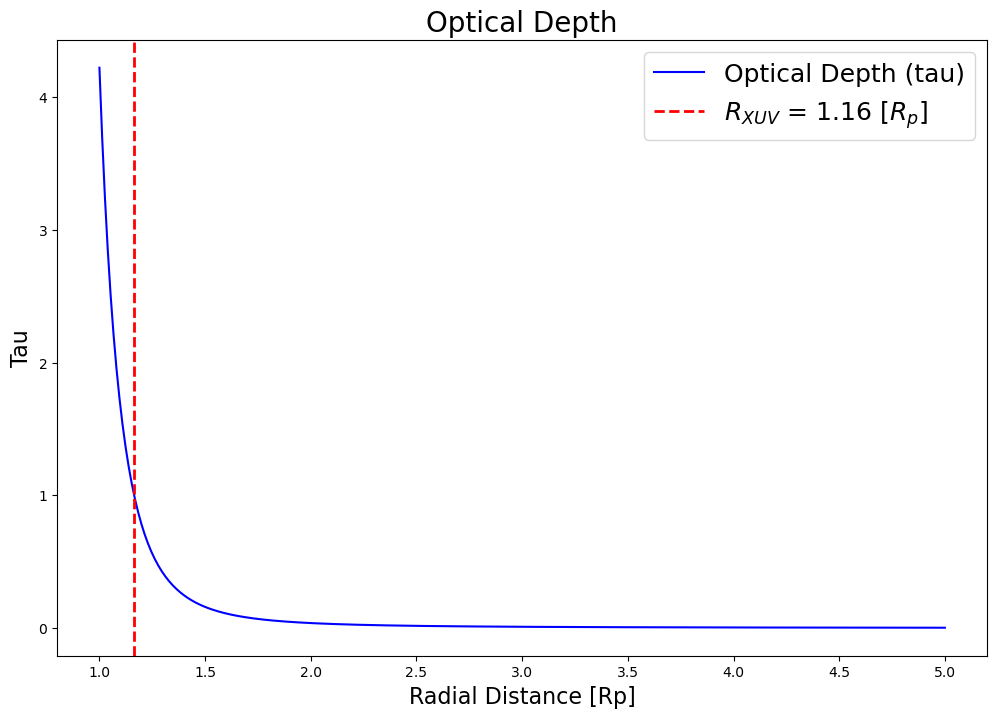

In [5]:
plt.figure(figsize=(12, 8))
plt.plot(r_range/rp, tau, label='Optical Depth (tau)', color='blue')
plt.axvline(rXUV/rp, color='red', linestyle='--', linewidth=2, 
            label=fr'$R_{{XUV}}$ = {round(rXUV/rp, 2)} [$R_p$]')
plt.title('Optical Depth', fontsize=20)
plt.xlabel(r'Radial Distance [Rp]', fontsize=16)
plt.ylabel(r'Tau', fontsize=16)
plt.legend(fontsize=18)
plt.show()

Compute Volumetric Heating Rate (Gamma) [W/m^3]


In [6]:
epsilon = 0.32 

Gamma = epsilon * FXUV * np.exp(-tau) * sigma_XUV * n

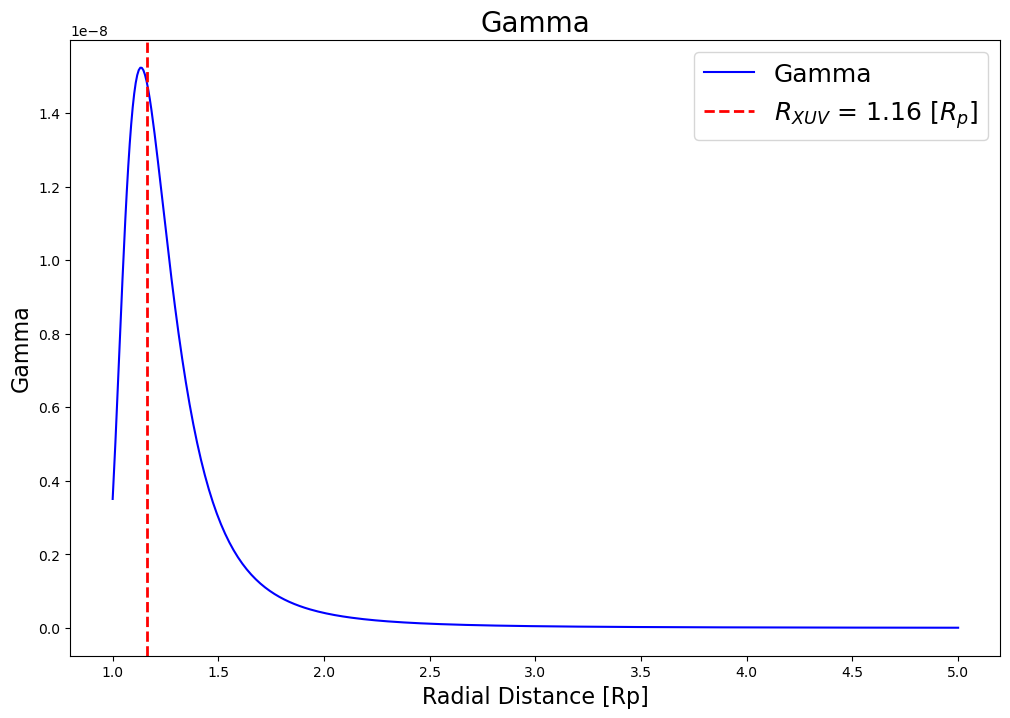

In [7]:
plt.figure(figsize=(12, 8))
plt.plot(r_range/rp, Gamma, label='Gamma', color='blue')
plt.axvline(rXUV/rp, color='red', linestyle='--', linewidth=2, 
            label=fr'$R_{{XUV}}$ = {round(rXUV/rp, 2)} [$R_p$]')
plt.title('Gamma', fontsize=20)
plt.xlabel(r'Radial Distance [Rp]', fontsize=16)
plt.ylabel(r'Gamma', fontsize=16)
plt.legend(fontsize=18)
plt.show()

Compute Global Heating Rate 

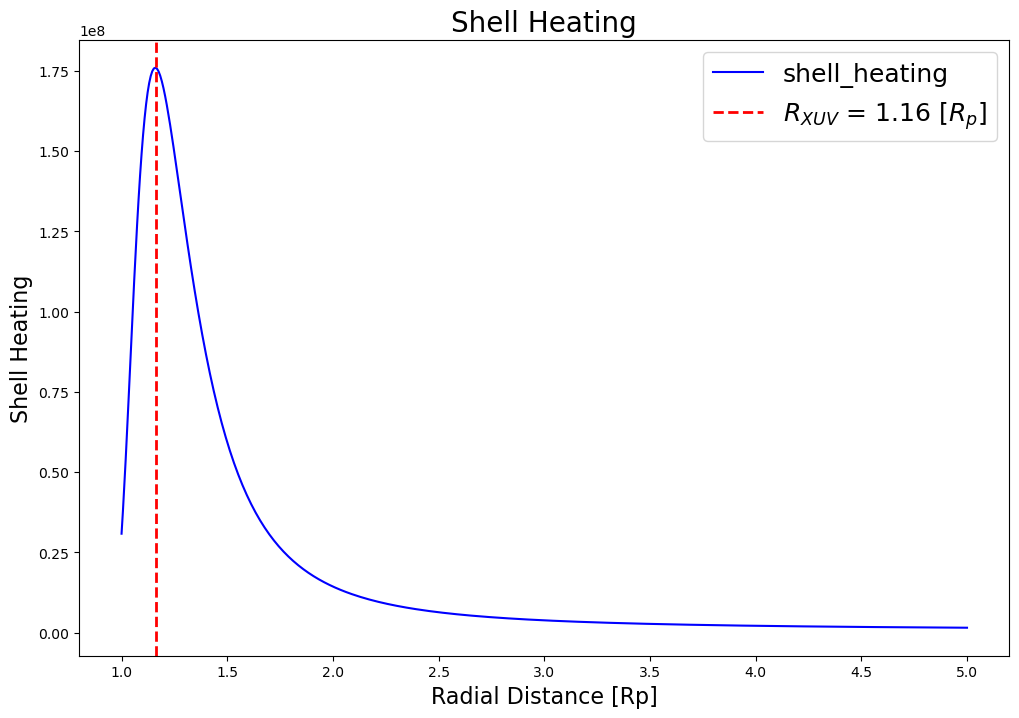

In [8]:
# Integrate Gamma * 4*pi*r^2 over the grid
shell_heating = Gamma * 4 * np.pi * r_range**2
Q_global = np.abs(np.trapezoid(shell_heating, r_range))


plt.figure(figsize=(12, 8))
plt.plot(r_range/rp, shell_heating, label='shell_heating', color='blue')
plt.axvline(rXUV/rp, color='red', linestyle='--', linewidth=2, 
            label=fr'$R_{{XUV}}$ = {round(rXUV/rp, 2)} [$R_p$]')
plt.title('Shell Heating', fontsize=20)
plt.xlabel(r'Radial Distance [Rp]', fontsize=16)
plt.ylabel(r'Shell Heating', fontsize=16)
plt.legend(fontsize=18)
plt.show()

In [9]:
# area under the curve to get Q_global
Q_global

np.float64(2273053440105293.5)

# Plank function

In [10]:
def planck_function(T,wavelength):
    """
    Planck function in wavelengh form. This function calculates the spectal radiance of a  body at a given temperature and wavelength. 
    In other words, this is the surface brightness or the intensity on the surface of the light emitting object. 

    Parameters
    ----------
    T : float
        Temperature in [K].
    wavelength : float
        Wavelength in [m].
    
    Returns
    -------
    planck_function : float
        Planck function in [W/m^2/sr/m].
    """

    ### import constants
    h = tools.h
    c = tools.c
    kB = tools.kB

    ### calculate Planck function
    planck_function = (2*h*c**2)/(wavelength**5) * 1/ (np.exp((h*c)/(wavelength*kB*T)) - 1)
    
    return planck_function

/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_59395/677772004.py:25: RuntimeWarning: overflow encountered in exp
  planck_function = (2*h*c**2)/(wavelength**5) * 1/ (np.exp((h*c)/(wavelength*kB*T)) - 1)
/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_59395/2125187417.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18)


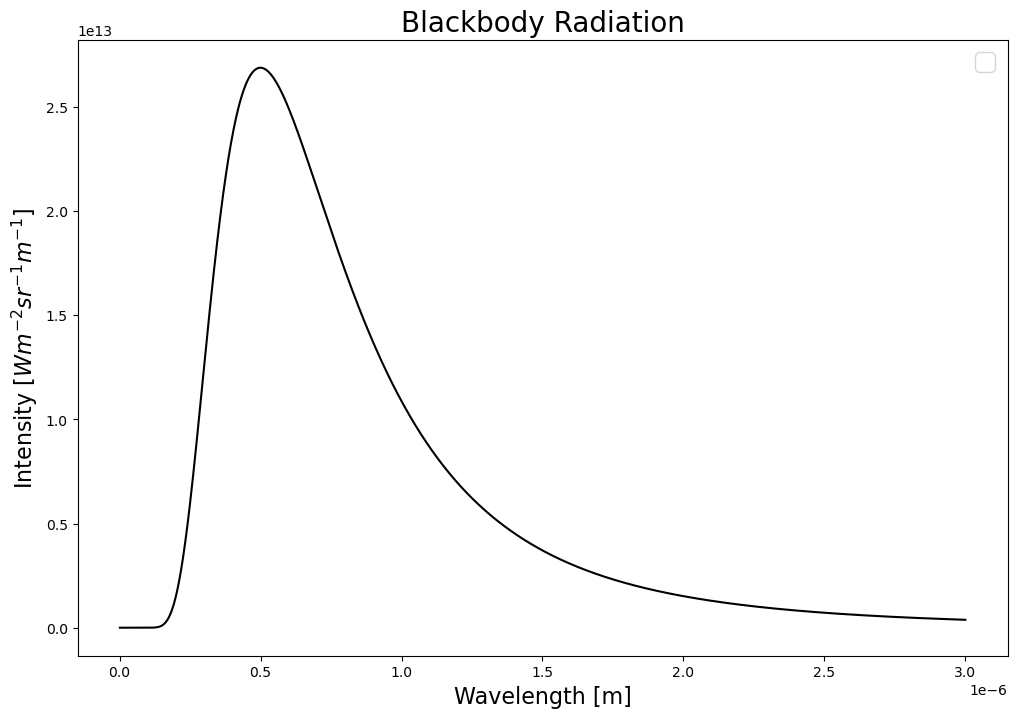

In [75]:
lambda_range = np.linspace(1e-9, 3000e-9,3000)
T_star = 5800
BB_lambda = planck_function(T_star, lambda_range)

plt.figure(figsize=(12, 8))
plt.plot(lambda_range, BB_lambda, color='black')
plt.title('Blackbody Radiation', fontsize=20)
plt.xlabel(r'Wavelength [m]', fontsize=16)
plt.ylabel(r'Intensity [$W m^{-2} sr^{-1} m^{-1}$]', fontsize=16)
plt.legend(fontsize=18)
plt.show()

/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_59395/677772004.py:25: RuntimeWarning: overflow encountered in exp
  planck_function = (2*h*c**2)/(wavelength**5) * 1/ (np.exp((h*c)/(wavelength*kB*T)) - 1)
/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_59395/2847712802.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18)


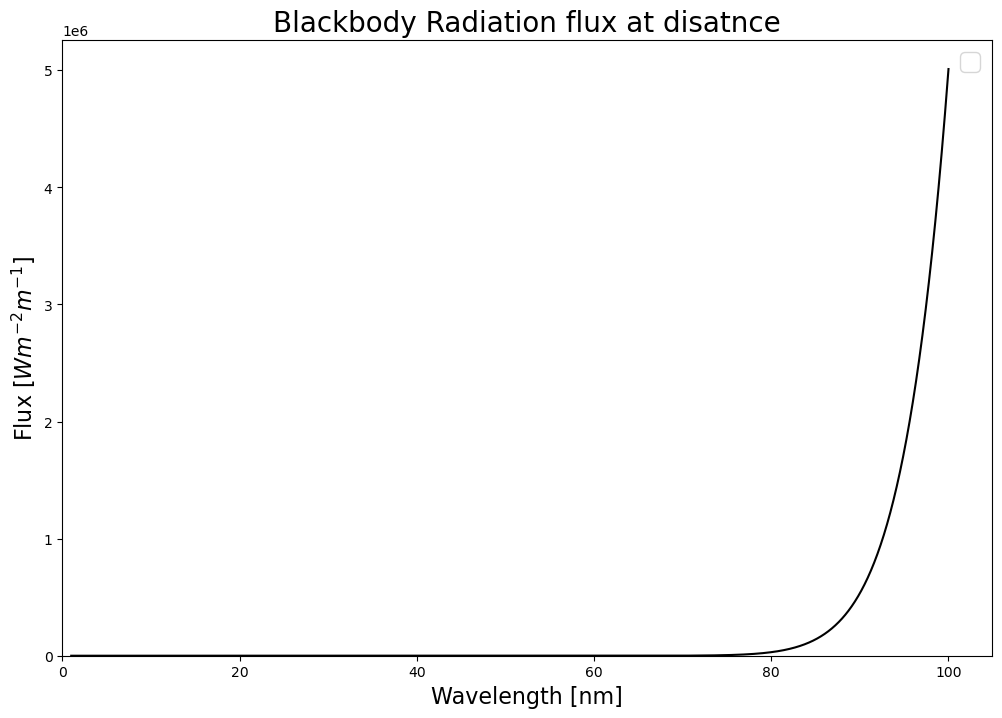

In [ ]:
def BB_flux(temperature, wavelength,r_star, distance):
    """
    Black body flux at a distance from the source.

    Parameters
    ----------
    temperature : float
        Temperature of the blackbody in [K].
    wavelength : float or array-like
        Wavelength in [m].
    rstar : float
        Radius of the star in [m].
    distance : float 
        Distance from the source in [m].
    Returns
    -------
    flux : float
        Flux in [W/m^2/m].
    """

    ### Convert intensity (spectral radiance) to flux (spectral irradiance) by integrating over the hemisphere. 
    ### Apply the inverse square law to calculate the flux at a distance from the source.

    #surface intensity on the star
    intensity = planck_function(temperature, wavelength) 

    # Convert intensity (spectral radiance) to flux (spectral irradiance) by integrating over the hemisphere: pi*intensity
    # Account for the star's surface area and apply the inverse square law to calculate the flux at a distance from the source: divide by (r_star/distance)^2 
    
    flux = intensity * np.pi * (r_star/distance)**2

    return flux

#### parameters 
T_star = 5780 # temperature of the star in [K]
r_star = 6.96e8 # radius of the star in [m]
distance = 0.05*tools.AU # distance from the star to the planet in [m]
lambda_range = np.linspace(1e-9, 100e-9,3000)
flux_array = BB_flux(T_star, lambda_range, r_star, distance)

plt.figure(figsize=(12, 8))
plt.plot(lambda_range*1e9, flux_array, color='black')
plt.title('Blackbody Radiation flux at disatnce', fontsize=20)
plt.xlabel(r'Wavelength [nm]', fontsize=16)
plt.ylabel(r'Flux [$W m^{-2} m^{-1}$]', fontsize=16)
plt.ylim(0)
plt.xlim(0)
plt.show()

In [ ]:
## setting integration limits and convert eV to meters
lambda_min = (tools.h * tools.c) / (40 * tools.eV) #31 nm
lambda_max = (tools.h * tools.c) / (13.6 * tools.eV) #91.2 nm

# --- Perform Integration ---
integrated_flux, error = quad(lambda x: BB_flux(T_star, x, r_star, distance),
                              lambda_min, 
                              lambda_max)

np.float64(9.116485178911785e-08)

In [67]:
integrated_flux * 1e3 #convert from W/m^2 to erg/s/cm^2

0.006654572690822382

### Sanity check that the BB function is correct, try to calculate the effective temperature of the earth

In [77]:
#### Sanity check that the BB function is correct, try to calculate the effective temperature of the earth
#### parameters 
T_star = 5780 # temperature of the star in [K]
r_star = 6.96e8 # radius of the star in [m]
distance = tools.AU # distance from the star to the planet in [m]
lambda_range = np.linspace(1e-9, 3000e-9,3000)
flux_array = BB_flux(T_star, lambda_range, r_star, distance)

## setting integration limits and convert eV to meters
# lambda_min = (tools.h * tools.c) / (40 * tools.eV) 
# lambda_max = (tools.h * tools.c) / (13.6 * tools.eV)
lambda_min = 1e-9
lambda_max = 3000e-9

# --- Perform Integration ---
flux_Earth, error = quad(lambda x: BB_flux(T_star, x, r_star, distance),
                              lambda_min, 
                              lambda_max)

T_eff_earth = ((flux_Earth)/(4*tools.sigma_sb))**(1/4)
print("effective temperature of Earth is:",T_eff_earth) 

effective temperature of Earth is: 277.2861904295691


/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_59395/677772004.py:25: RuntimeWarning: overflow encountered in exp
  planck_function = (2*h*c**2)/(wavelength**5) * 1/ (np.exp((h*c)/(wavelength*kB*T)) - 1)


In [ ]:
 (tools.h * tools.c) / (40 * tools.eV) 

# Realistic solar SED

<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/nd/pn3mw1xj703gtgppx79rsh0c0000gn/T/ipykernel_59395/3444763608.py:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(file_path, sep='\s+', comment='#', names=['wavelength_nm', 'flux'], header=None)


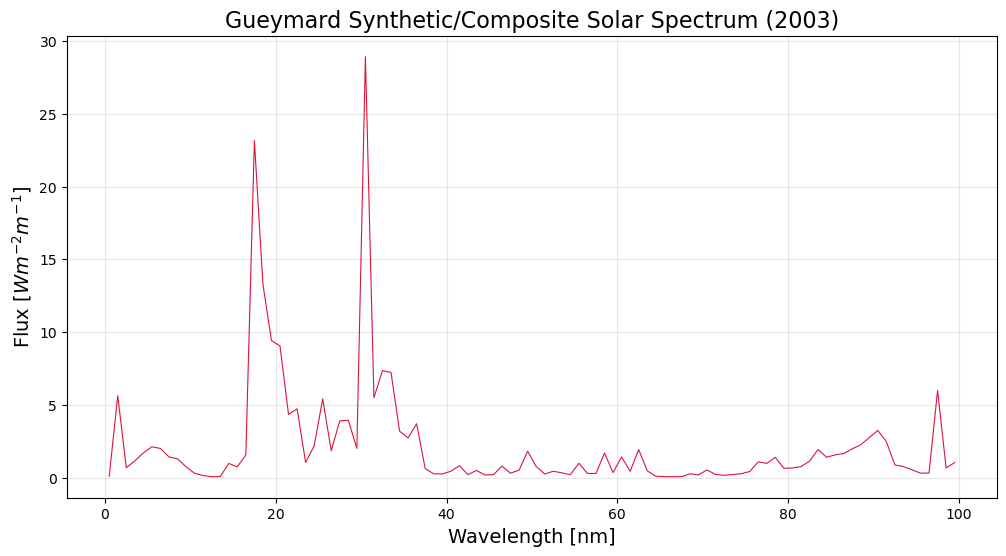

In [57]:
# 1. Load the data
# sep='\s+' handles both tabs and multiple spaces
# comment='#' ignores the header line
file_path = 'SEDs/Gueymard_solar.txt'
df = pd.read_csv(file_path, sep='\s+', comment='#', names=['wavelength_nm', 'flux'], header=None)

# define the wavelength range of interest
df_range = df[(df['wavelength_nm'] >= 0) & (df['wavelength_nm'] <= 100)]

# 2. Plot the spectrum
plt.figure(figsize=(12, 6))
plt.plot(df_range['wavelength_nm'], df_range['flux']/1e3, color='crimson', linewidth=0.8)

# Log scale is highly recommended because flux drops off fast in the UV
# plt.yscale('log') 

plt.xlabel('Wavelength [nm]', fontsize=14)
plt.ylabel(r'Flux [$W m^{-2} m^{-1}$]', fontsize=14)
plt.title('Gueymard Synthetic/Composite Solar Spectrum (2003)', fontsize=16)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

In [83]:
mask = (df['wavelength_nm'] >= 31) & (df['wavelength_nm'] <= 91.2)
euv_band = df[mask]

distance = 0.05*tools.AU # distance from the star to the planet in [m]
scale_factor = (r_star/distance)**2

# Integrate using the trapezoidal rule
total_flux_erg = np.trapezoid(euv_band['flux']*scale_factor, euv_band['wavelength_nm'])
total_flux_erg #[ergs/cm**2/s]


np.float64(597.2325511272358)

# Weighted average flux?

In [91]:
weighted_average = np.average(euv_band['wavelength_nm'], weights=euv_band['flux'])

print("flux weighted average wavelength is:", weighted_average, "nm or", tools.h * tools.c/(tools.eV*weighted_average*1e-9), "eV")

flux weighted average wavelength is: 56.0837273013167 nm or 22.106982613170477 eV


# Photoionisation cross section

In [ ]:
def photoionization_cross_section(E, sigma_0, E_0, y_0, y_1, y_w, P, y_a):
    """
    Calculates the photoionization cross-section using the Verner (1996) analytic fits.
    
    Parameters
    ----------
    E       : float or np.array : Photon energy [eV]
    sigma_0 : float             : Fit parameter [Megabarns]
    E_0     : float             : Fit parameter [eV]
    y_0     : float             : Fit parameter
    y_1     : float             : Fit parameter
    y_w     : float             : Fit parameter
    P       : float             : Fit parameter
    y_a     : float             : Fit parameter
    
    Returns
    -------
    sigma_m2 : float or np.array : Cross-section in [m^2]
    """
    
    # 1. Calculate x
    x = (E / E_0) - y_0
    
    # 2. Calculate y
    y = np.sqrt(x**2 + y_1**2)
    
    # 3. Calculate the F(y) function
    term1 = (x - 1)**2 + y_w**2
    term2 = y**(0.5 * P - 5.5)
    term3 = (1 + np.sqrt(y / y_a))**(-P)
    
    F_y = term1 * term2 * term3
    
    # 4. Calculate total cross-section in Megabarns (Mb)
    sigma_Mb = sigma_0 * F_y
    
    # Convert Megabarns to m^2 (1 Megabarn = 1e-18 cm^2 = 1e-22 m^2)
    sigma_m2 = sigma_Mb * 1e-22
    
    return sigma_m2

# --- Example Usage for Neutral Hydrogen (H I) ---
# Parameters for H I from Verner et al. (1996) Table 1
H_params = {
    "sigma_0": 5.475e4,
    "E_0": 0.4298,
    "y_0": 0.0,
    "y_1": 0.0,
    "y_w": 0.0,
    "P": 2.963,
    "y_a": 32.88
}

# Test with a typical effective XUV energy
energy_eV = 20.0

sigma = photoionization_cross_section(energy_eV, **H_params)

print(f"Photon Energy: {energy_eV} eV")
print(f"Cross-section: {sigma:.2e} m^2")

Photon Energy: 20.0 eV
Cross-section: 2.21e-22 m^2
